<a href="https://colab.research.google.com/github/miriamamin1213-ux/FinalModels/blob/main/CNN_Hecktor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Downloading...
From: https://drive.google.com/uc?id=1DGDH2e6dEkpdwwtCvH6ds1CwJT2Hdmkv
To: /content/HPV2025.xlsx
100%|██████████| 66.0k/66.0k [00:00<00:00, 31.1MB/s]
/tmp/ipykernel_5142/1782266391.py:41: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["T-stage"]=df["T-stage"].replace({"T0":0,"T1":1,"T2":2,"T3":3,"T4":4})
/tmp/ipykernel_5142/1782266391.py:42: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["N-stage"]=df["N-stage"].replace({"N0":0,"N1":1,"N2":2,"N3":3})
/tmp/ipykernel_5142/1782266391.py:43: FutureWarning: Downcasti

Number of features: 11

Training samples without SMOTE:
HPV Status
1.0    424
0.0     46
Name: count, dtype: int64

Test samples:
HPV Status
1.0    106
0.0     12
Name: count, dtype: int64
Epoch 50, Train=0.6770, Test=0.6847, BA=0.6101, AUC=0.6399
Epoch 100, Train=0.6437, Test=0.6587, BA=0.6690, AUC=0.7484
Epoch 150, Train=0.5946, Test=0.6215, BA=0.6187, AUC=0.7901
Epoch 200, Train=0.5393, Test=0.5835, BA=0.6604, AUC=0.8074
Epoch 250, Train=0.4847, Test=0.5472, BA=0.6973, AUC=0.8215
Epoch 300, Train=0.4394, Test=0.5287, BA=0.7390, AUC=0.8294
Epoch 350, Train=0.4067, Test=0.5266, BA=0.7437, AUC=0.8310
Epoch 400, Train=0.3829, Test=0.5384, BA=0.7115, AUC=0.8286
Epoch 450, Train=0.3643, Test=0.5573, BA=0.7115, AUC=0.8255
Epoch 500, Train=0.3486, Test=0.5817, BA=0.7115, AUC=0.8215

Best Test Loss = 0.5257 Epoch = 331
Best Test BA   = 0.7437 Epoch = 311
Best Test AUC  = 0.8325 Epoch = 359

CNN HECKTOR - Best Test Loss

Classification Report

              precision    recall  f1-score   sup

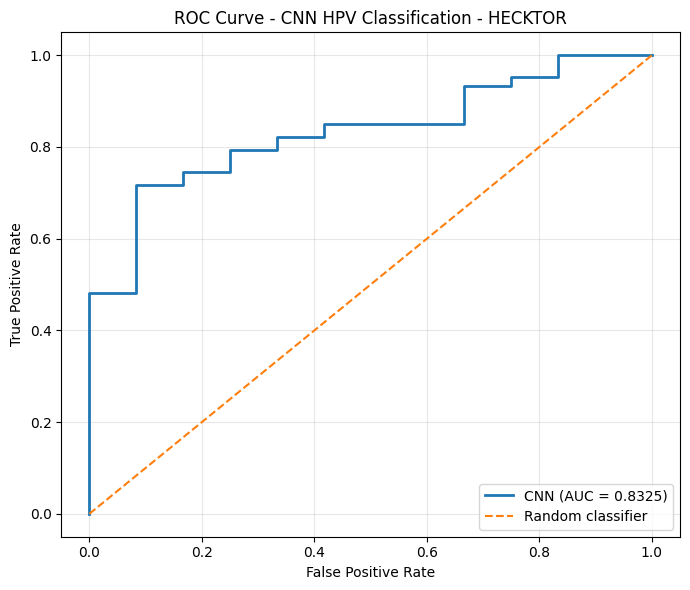

AUC: 0.8325

CNN42_HECKTOR SUMMARY
Architecture : Conv16-FC32-FC16-2
Input Features : 11
Learning Rate : 0.0001
Optimiser : Adam
Class Weights : Automatic from training set
Encoding : LabelEncoder
SMOTE : No
Split : Stratified 80/20
Preprocessing : Train-only
Scaling : StandardScaler fit on training set
Gradient Clipping : No
Epochs : 500
Best Test Loss Epoch : 331
Best Test BA Epoch : 311
Best Test AUC Epoch : 359
Training Patients : 470
Test Patients : 118
Seed : 42


In [1]:
# ============================================================
# CNN42_HECKTOR - NO SMOTE
# ============================================================

!pip install -q gdown

import gdown
gdown.download(id="1DGDH2e6dEkpdwwtCvH6ds1CwJT2Hdmkv",output="HPV2025.xlsx",quiet=False)

import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import classification_report,confusion_matrix,balanced_accuracy_score,roc_auc_score,f1_score,roc_curve

def seed_everything(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ["PYTHONHASHSEED"]=str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"]=":4096:8"
    torch.use_deterministic_algorithms(True,warn_only=True)
    torch.backends.cudnn.deterministic=True
    torch.backends.cudnn.benchmark=False
    torch.backends.cuda.matmul.allow_tf32=False
    torch.backends.cudnn.allow_tf32=False

SEED=42
seed_everything(SEED)

df=pd.read_excel("HPV2025.xlsx")
df=df.dropna(subset=["HPV Status"])
df=df.drop(columns=["PatientID","CenterID","Task 1","Task 2","Task 3"])

df["T-stage"]=df["T-stage"].replace({"T0":0,"T1":1,"T2":2,"T3":3,"T4":4})
df["N-stage"]=df["N-stage"].replace({"N0":0,"N1":1,"N2":2,"N3":3})
df["M-stage"]=df["M-stage"].replace({"M0":0,"M1":1})

features=[
    "Age","Gender","Tobacco Consumption","Alcohol Consumption",
    "Performance Status","Relapse","RFS","Treatment",
    "T-stage","N-stage","M-stage"
]
cat_cols=[
    "Gender","Tobacco Consumption","Alcohol Consumption",
    "Performance Status","Relapse","Treatment"
]
num_cols=["Age","RFS","T-stage","N-stage","M-stage"]

X=df[features].copy()
y=df["HPV Status"].copy()

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.20,random_state=SEED,stratify=y
)

for col in cat_cols:
    mode=X_train[col].mode()
    fill_value=mode.iloc[0] if len(mode)>0 else "Unknown"
    X_train[col]=X_train[col].fillna(fill_value)
    X_test[col]=X_test[col].fillna(fill_value)

for col in num_cols:
    median=X_train[col].median()
    X_train[col]=X_train[col].fillna(median)
    X_test[col]=X_test[col].fillna(median)

for col in cat_cols:
    encoder=LabelEncoder()
    X_train[col]=encoder.fit_transform(X_train[col].astype(str))
    known=set(encoder.classes_)
    X_test[col]=X_test[col].astype(str).map(
        lambda x: encoder.transform([x])[0] if x in known else -1
    )

n_features=X_train.shape[1]
print("Number of features:",n_features)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

print("\nTraining samples without SMOTE:")
print(y_train.value_counts())
print("\nTest samples:")
print(y_test.value_counts())

X_train=torch.FloatTensor(X_train).unsqueeze(1)
X_test=torch.FloatTensor(X_test).unsqueeze(1)
y_train=torch.LongTensor(y_train.to_numpy())
y_test=torch.LongTensor(y_test.to_numpy())

class HPVCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1=nn.Conv1d(
            in_channels=1,out_channels=16,
            kernel_size=3,padding=1
        )
        self.relu=nn.ReLU()
        self.flatten=nn.Flatten()
        self.fc1=nn.Linear(16*n_features,32)
        self.fc2=nn.Linear(32,16)
        self.fc3=nn.Linear(16,2)

    def forward(self,x):
        x=self.conv1(x)
        x=self.relu(x)
        x=self.flatten(x)
        x=self.relu(self.fc1(x))
        x=self.relu(self.fc2(x))
        return self.fc3(x)

model=HPVCNN()

class_counts=np.bincount(y_train.numpy())
class_weights=len(y_train)/(len(class_counts)*class_counts)
class_weights=torch.tensor(class_weights,dtype=torch.float32)

criterion=nn.CrossEntropyLoss(weight=class_weights)
optimizer=torch.optim.Adam(model.parameters(),lr=0.0001)

epochs=500
best_test_loss=float("inf")
best_test_ba=-1
best_test_auc=-1
best_loss_epoch=0
best_ba_epoch=0
best_auc_epoch=0

for epoch in range(epochs):
    model.train()
    outputs=model(X_train)
    train_loss=criterion(outputs,y_train)
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        test_outputs=model(X_test)
        test_loss=criterion(test_outputs,y_test)
        test_probabilities=torch.softmax(
            test_outputs,dim=1
        )[:,1]
        test_predicted=torch.argmax(test_outputs,dim=1)

    test_ba=balanced_accuracy_score(
        y_test.numpy(),test_predicted.numpy()
    )
    test_auc=roc_auc_score(
        y_test.numpy(),test_probabilities.numpy()
    )

    if test_loss.item()<best_test_loss:
        best_test_loss=test_loss.item()
        best_loss_epoch=epoch+1
        torch.save(
            model.state_dict(),
            "best_cnn_hecktor_loss.pth"
        )

    if test_ba>best_test_ba:
        best_test_ba=test_ba
        best_ba_epoch=epoch+1
        torch.save(
            model.state_dict(),
            "best_cnn_hecktor_ba.pth"
        )

    if test_auc>best_test_auc:
        best_test_auc=test_auc
        best_auc_epoch=epoch+1
        torch.save(
            model.state_dict(),
            "best_cnn_hecktor_auc.pth"
        )

    if (epoch+1)%50==0:
        print(
            f"Epoch {epoch+1}, "
            f"Train={train_loss.item():.4f}, "
            f"Test={test_loss.item():.4f}, "
            f"BA={test_ba:.4f}, "
            f"AUC={test_auc:.4f}"
        )

print("\nBest Test Loss =",round(best_test_loss,4),
      "Epoch =",best_loss_epoch)
print("Best Test BA   =",round(best_test_ba,4),
      "Epoch =",best_ba_epoch)
print("Best Test AUC  =",round(best_test_auc,4),
      "Epoch =",best_auc_epoch)

def evaluate_checkpoint(path,name):
    model.load_state_dict(
        torch.load(path,map_location="cpu")
    )
    model.eval()

    with torch.no_grad():
        outputs=model(X_test)
        probabilities=torch.softmax(outputs,dim=1)
        predicted=torch.argmax(outputs,dim=1)

    y_true=y_test.numpy()
    y_pred=predicted.numpy()
    y_score=probabilities[:,1].numpy()

    accuracy=(y_pred==y_true).mean()
    bal_acc=balanced_accuracy_score(y_true,y_pred)
    f1=f1_score(y_true,y_pred)
    auc=roc_auc_score(y_true,y_score)

    print("\n====================================")
    print(name)
    print("====================================")
    print("\nClassification Report\n")
    print(classification_report(
        y_true,y_pred,digits=4
    ))
    print("Confusion Matrix")
    print(confusion_matrix(y_true,y_pred))
    print(f"Accuracy:            {accuracy:.4f}")
    print(f"Balanced Accuracy:   {bal_acc:.4f}")
    print(f"F1-score:            {f1:.4f}")
    print(f"AUC:                 {auc:.4f}")

    return y_score,auc

prob_loss,auc_loss=evaluate_checkpoint(
    "best_cnn_hecktor_loss.pth",
    "CNN HECKTOR - Best Test Loss"
)

prob_ba,auc_ba=evaluate_checkpoint(
    "best_cnn_hecktor_ba.pth",
    "CNN HECKTOR - Best Test Balanced Accuracy"
)

prob_auc,auc_auc=evaluate_checkpoint(
    "best_cnn_hecktor_auc.pth",
    "CNN HECKTOR - Best Test AUC"
)

model.load_state_dict(
    torch.load(
        "best_cnn_hecktor_auc.pth",
        map_location="cpu"
    )
)
model.eval()

with torch.no_grad():
    outputs=model(X_test)
    probabilities=torch.softmax(outputs,dim=1)

y_score=probabilities[:,1].numpy()
fpr,tpr,_=roc_curve(y_test.numpy(),y_score)
auc=roc_auc_score(y_test.numpy(),y_score)

plt.figure(figsize=(7,6))
plt.plot(
    fpr,tpr,linewidth=2,
    label=f'CNN (AUC = {auc:.4f})'
)
plt.plot(
    [0,1],[0,1],
    linestyle='--',
    linewidth=1.5,
    label='Random classifier'
)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - CNN HPV Classification - HECKTOR')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC: {auc:.4f}")

print("\n====================================")
print("CNN42_HECKTOR SUMMARY")
print("====================================")
print("Architecture : Conv16-FC32-FC16-2")
print("Input Features :",n_features)
print("Learning Rate : 0.0001")
print("Optimiser : Adam")
print("Class Weights : Automatic from training set")
print("Encoding : LabelEncoder")
print("SMOTE : No")
print("Split : Stratified 80/20")
print("Preprocessing : Train-only")
print("Scaling : StandardScaler fit on training set")
print("Gradient Clipping : No")
print("Epochs : 500")
print("Best Test Loss Epoch :",best_loss_epoch)
print("Best Test BA Epoch :",best_ba_epoch)
print("Best Test AUC Epoch :",best_auc_epoch)
print("Training Patients :",len(y_train))
print("Test Patients :",len(y_test))
print("Seed :",SEED)